In [1]:
from adam import Adam
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(-10, 10, 100)
y = np.linspace(-5, 5, 50)

X, Y = np.meshgrid(x, y)

In [3]:
def f(x):
    return x[0]**2 / 20.0 + x[1]**2
def df(x):
    return np.array([x[0]/10.0, 2.0*x[1]])

In [4]:
optimizer = Adam(lr=0.3)

In [5]:
init = [-7.0, 2.0]
params = {}
params['x'], params['y'] = init[0], init[1]
grads = {}
grads['x'], grads['y'] = 0, 0
point_list = []
point_list.append(init)

In [6]:
for i in range(30):
    g = df(np.array([params['x'], params['y']]))
    grads['x'] = g[0]
    grads['y'] = g[1]
    optimizer.update(params, grads)
    point_list.append([params['x'], params['y']])

최종 위치: [0.13600685 0.31824538]
최종 함수값: 0.10220501224574535


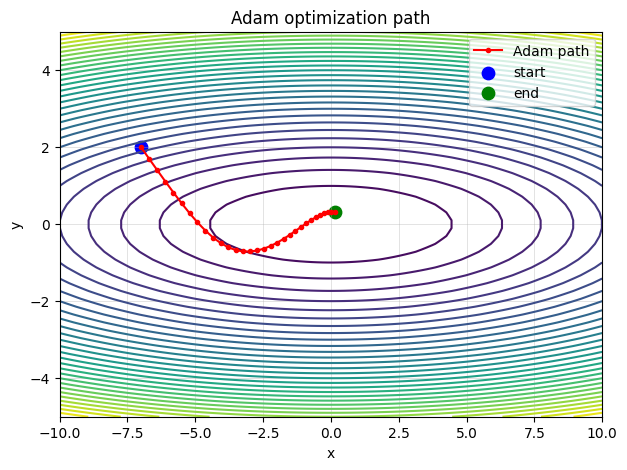

In [7]:
point_list = np.array(point_list)

print("최종 위치:", point_list[-1])
print("최종 함수값:", f(point_list[-1]))

Z = 1 / 20 * X**2 + Y**2

plt.figure(figsize=(7, 5))
plt.contour(X, Y, Z, levels=30)

plt.plot(point_list[:, 0], point_list[:, 1], "o-", color="red", markersize=3, label="Adam path")
plt.scatter(init[0], init[1], color="blue", s=80, label="start")
plt.scatter(point_list[-1, 0], point_list[-1, 1], color="green", s=80, label="end")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Adam optimization path")
plt.legend()
plt.grid(True)
plt.show()